# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [94]:
import numpy as np
import seaborn as sns
import pandas as pd

/var/folders/xp/db574fvx2lq4165qj0ww45r40000gp/T/ipykernel_10986/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

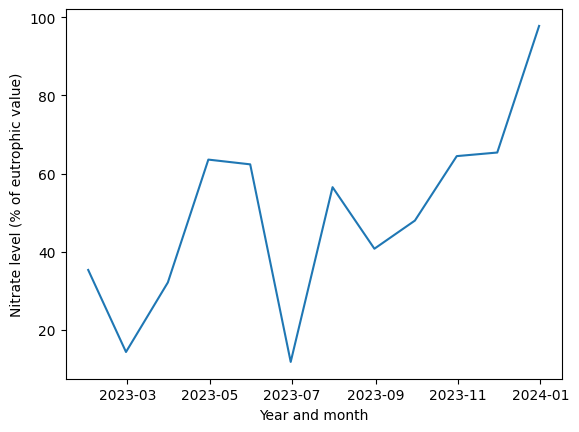

In [95]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/var/folders/xp/db574fvx2lq4165qj0ww45r40000gp/T/ipykernel_10986/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

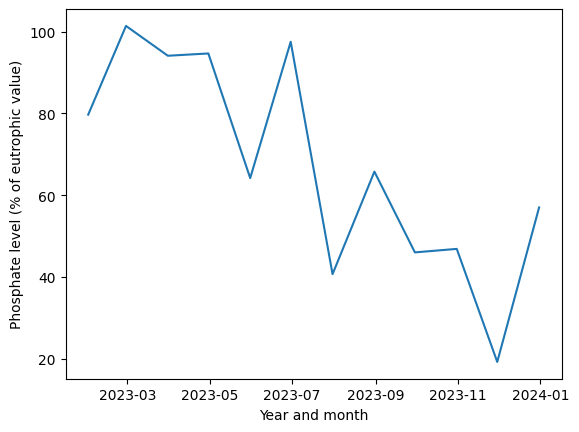

In [96]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

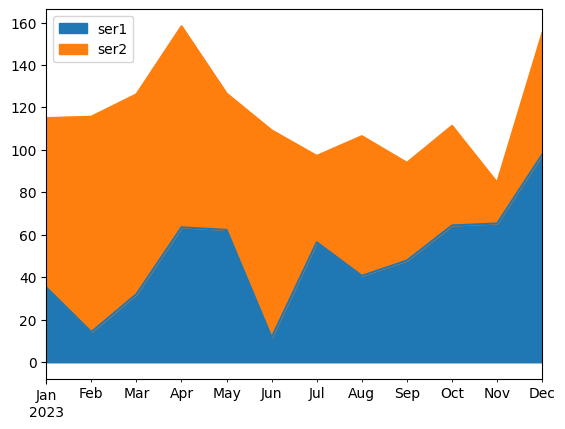

In [105]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

## Area Plot vs Two Line Graphs: Nitrate and Phosphate Levels

### Two Separate Line Graphs
**Pros:**
- Better when the two variables have different scales or ranges — each
  gets its own y-axis so neither gets compressed
- Easier to read individually with no risk of misinterpreting overlap
- Clearer when the variables are moving in opposite directions, as they
  are here (nitrate rising, phosphate falling)

**Cons:**
- Harder to compare the two variables side by side
- Requires the reader to look at two separate charts

### Area Plot
**Pros:**
- Shows both variables in one view is good for comparing overall magnitude
- Visually intuitive when one variable is a subset of another

**Cons:**
- Stacked vs overlapping areas are easy to confuse; stacked implies the
  total is meaningful, which is not the case here
- When variables move in opposite directions like nitrate and phosphate,
  the overlapping areas become hard to read
- The orange area here appears to be phosphate stacked on top of nitrate,
  which distorts the actual phosphate values

### Suggested Improvements
- Add a title to all three charts
- Label both series clearly — "ser1/ser2" is not informative
- For the area plot, use `stacked=False` with higher alpha transparency
  so both series are visible without distortion

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [97]:
SAMPLE_SIZE = 50000 # some of the data sets are large 

def load_csv_sampled(filepath, sample_size=SAMPLE_SIZE, random_state=42, sep=None, encoding=None, **kwargs):
    # try encodings in order
    encodings = [encoding] if encoding else ['utf-8', 'latin-1', 'cp1252']
    
    for enc in encodings:
        try:
            # auto-detect delimiter
            if sep is None:
                with open(filepath, 'r', encoding=enc) as f:
                    first_line = f.readline()
                    sep = '\t' if '\t' in first_line else ','
            
            row_count = sum(1 for _ in open(filepath, encoding=enc)) - 1
            
            if sample_size and row_count > sample_size:
                np.random.seed(random_state)
                skip_idx = np.random.choice(range(1, row_count + 1), size=int(row_count * (1 - sample_size/row_count)), replace=False)
                df = pd.read_csv(filepath, skiprows=skip_idx, sep=sep, thousands=',', encoding=enc, **kwargs)
                print(f"Loaded {len(df):,} rows (sampled from {row_count:,}) [encoding: {enc}]")
            else:
                df = pd.read_csv(filepath, sep=sep, thousands=',', encoding=enc, **kwargs)
                print(f"Loaded {len(df):,} rows [encoding: {enc}]")
            return df
        except UnicodeDecodeError:
            continue
    
    raise ValueError(f"Could not decode file with encodings: {encodings}")

DATASET_US_ECOMM_1 = "data_us_ecommerce_records_sampled"
DATASET_US_ECOMM_2 = "data_ecommerce_behavior_from_multi_category_store_sampled"
DATASET_INSTACART  = "data_instacart_combined_sampled"

df_us_ecomm_1 = load_csv_sampled("data_us_ecommerce_records_sampled.csv")
df_us_ecomm_2 = load_csv_sampled("data_ecommerce_behavior_from_multi_category_store_sampled.csv")
df_instacart  = load_csv_sampled("data_instacart_combined_sampled.csv")



Loaded 3,312 rows [encoding: utf-8]
Loaded 50,000 rows [encoding: utf-8]
Loaded 50,000 rows [encoding: utf-8]


In [98]:
## Bivariate helpers
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_pairplot(df, numeric_cols, hue_col=None, sample_n=1000):
    data = df[numeric_cols + ([hue_col] if hue_col else [])].dropna()
    if len(data) > sample_n:
        data = data.sample(sample_n, random_state=42)
    g = sns.pairplot(data, hue=hue_col, plot_kws={'alpha': 0.3, 's': 15},
                     diag_kind='kde', palette='tab10')
    g.fig.suptitle('Pairplot' + (f' by {hue_col}' if hue_col else ''), y=1.02)
    plt.show()


def plot_line_by_time(df, time_col, numeric_col, ax, groupby_col=None, agg='mean'):
    if groupby_col:
        for group, gdf in df.groupby(groupby_col):
            agg_data = gdf.groupby(time_col)[numeric_col].agg(agg).sort_index()
            ax.plot(agg_data.index, agg_data.values, label=str(group), alpha=0.8)
        ax.legend(fontsize=7, title=groupby_col)
    else:
        agg_data = df.groupby(time_col)[numeric_col].agg(agg).sort_index()
        ax.fill_between(agg_data.index, agg_data.values, alpha=0.3, color='steelblue')
        ax.plot(agg_data.index, agg_data.values, color='steelblue', linewidth=2)
    ax.set_title(f'{agg.capitalize()} {numeric_col} by {time_col}')
    ax.set_xlabel(time_col)
    ax.set_ylabel(f'{agg} {numeric_col}')


def plot_correlation_heatmap(df, numeric_cols, ax):
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
    ax.set_title('Correlation Matrix')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)


def plot_boxplot_by_category(df, numeric_col, cat_col, ax, top_n=10):
    top_cats = df[cat_col].value_counts().head(top_n).index
    data = df[df[cat_col].isin(top_cats)]
    sns.boxplot(data=data, x=cat_col, y=numeric_col, ax=ax,
                palette='Set2', order=top_cats)
    ax.set_title(f'{numeric_col} by {cat_col} (top {top_n})')
    ax.tick_params(axis='x', rotation=40)


def plot_grouped_bar(df, cat_col, numeric_col, ax, top_n=10, agg='mean'):
    grouped = df.groupby(cat_col)[numeric_col].agg(agg).sort_values(ascending=False).head(top_n)
    grouped.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{agg.capitalize()} {numeric_col} by {cat_col} (top {top_n})')
    ax.set_xlabel(cat_col)
    ax.set_ylabel(f'{agg} {numeric_col}')
    ax.tick_params(axis='x', rotation=40)


def plot_heatmap_two_categoricals(df, col_x, col_y, ax, top_n=10):
    top_x = df[col_x].value_counts().head(top_n).index
    top_y = df[col_y].value_counts().head(top_n).index
    pivot = df[df[col_x].isin(top_x) & df[col_y].isin(top_y)]\
              .groupby([col_y, col_x]).size().unstack(fill_value=0)
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.3,
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'Count Heatmap: {col_y} vs {col_x}')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)


def plot_scatter(df, col_x, col_y, ax, sample_n=2000, hue_col=None):
    data = df[[col_x, col_y] + ([hue_col] if hue_col else [])].dropna()
    if len(data) > sample_n:
        data = data.sample(sample_n, random_state=42)
    sns.scatterplot(data=data, x=col_x, y=col_y, ax=ax,
                    hue=hue_col, alpha=0.4, s=20,
                    palette='tab10' if hue_col else None)
    ax.set_title(f'{col_x} vs {col_y}' + (f' (by {hue_col})' if hue_col else ''))


def analyze_dataset_bi_variate(
    df,
    numeric_cols=None,            # list of numeric cols for correlation heatmap
    boxplot_pairs=None,           # list of (numeric_col, cat_col)
    grouped_bar_pairs=None,       # list of (cat_col, numeric_col, agg) — agg: 'mean' | 'sum' | 'median'
    heatmap_pairs=None,           # list of (col_x, col_y) — two categoricals
    scatter_pairs=None,           # list of (col_x, col_y) or (col_x, col_y, hue_col)
    pairplot_cols=None,      # (numeric_cols_list, optional hue_col)
    line_pairs=None,          # list of (time_col, numeric_col, agg) or (time_col, numeric_col, agg, groupby_col)
    dataset_name='Dataset'
):
    print(f"{'='*100}")
    print(f"  {dataset_name} — Bivariate Analysis")
    print(f"{'='*100}")

    # Correlation heatmap
    if numeric_cols:
        print("\n--- Correlation Matrix ---")
        fig, ax = plt.subplots(figsize=(10, 8))
        plot_correlation_heatmap(df, numeric_cols, ax)
        plt.tight_layout()
        plt.show()

    # Boxplots
    if boxplot_pairs:
        print("\n--- Boxplots ---")
        for numeric_col, cat_col in boxplot_pairs:
            fig, ax = plt.subplots(figsize=(12, 5))
            plot_boxplot_by_category(df, numeric_col, cat_col, ax)
            plt.tight_layout()
            plt.show()

    # Grouped bar charts
    if grouped_bar_pairs:
        print("\n--- Grouped Bar Charts ---")
        for cat_col, numeric_col, agg in grouped_bar_pairs:
            fig, ax = plt.subplots(figsize=(12, 5))
            plot_grouped_bar(df, cat_col, numeric_col, ax, agg=agg)
            plt.tight_layout()
            plt.show()

    # Two-categorical heatmaps
    if heatmap_pairs:
        print("\n--- Category Heatmaps ---")
        for col_x, col_y in heatmap_pairs:
            fig, ax = plt.subplots(figsize=(12, 6))
            plot_heatmap_two_categoricals(df, col_x, col_y, ax)
            plt.tight_layout()
            plt.show()

    # Scatter plots
    if scatter_pairs:
        print("\n--- Scatter Plots ---")
        for pair in scatter_pairs:
            col_x, col_y = pair[0], pair[1]
            hue_col = pair[2] if len(pair) == 3 else None
            fig, ax = plt.subplots(figsize=(10, 6))
            plot_scatter(df, col_x, col_y, ax, hue_col=hue_col)
            plt.tight_layout()
            plt.show()
    # Pairplot
    if pairplot_cols:
        print("\n--- Pairplot ---")
        cols, hue_col = pairplot_cols[0], pairplot_cols[1] if len(pairplot_cols) > 1 else None
        plot_pairplot(df, cols, hue_col=hue_col)

    # Line / area graphs
    if line_pairs:
        print("\n--- Line / Area Graphs ---")
        for pair in line_pairs:
            time_col, numeric_col, agg = pair[0], pair[1], pair[2]
            groupby_col = pair[3] if len(pair) == 4 else None
            fig, ax = plt.subplots(figsize=(12, 5))
            plot_line_by_time(df, time_col, numeric_col, ax, groupby_col=groupby_col, agg=agg)
            plt.tight_layout()
            plt.show()

  US E-Commerce Records — Bivariate Analysis

--- Correlation Matrix ---


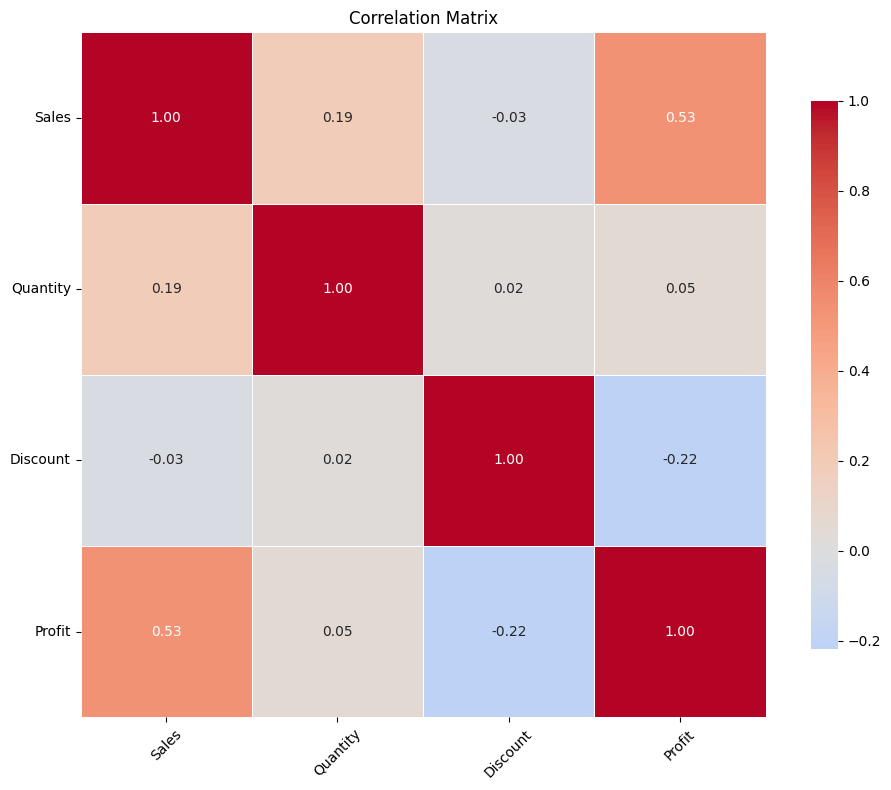


--- Grouped Bar Charts ---


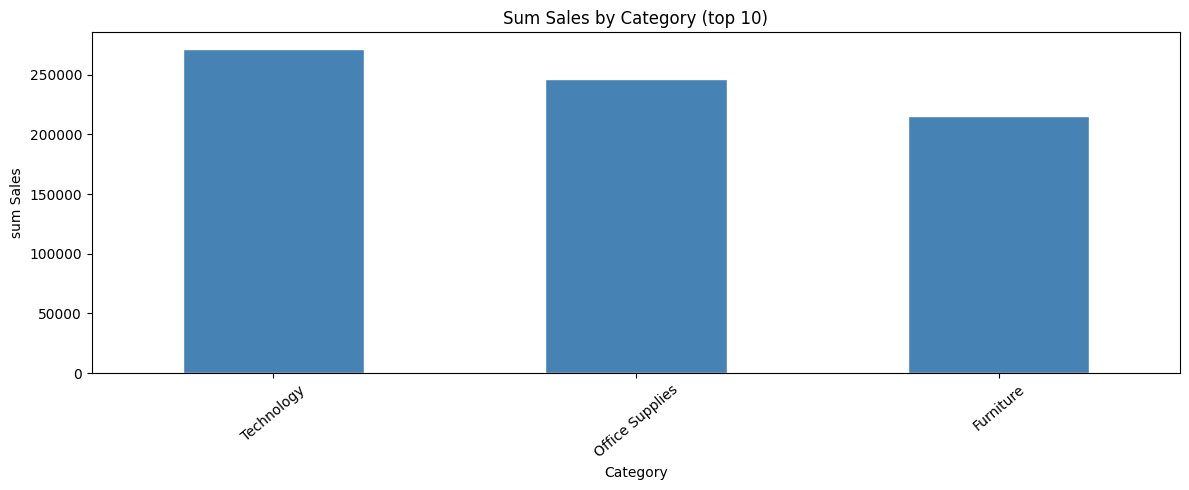

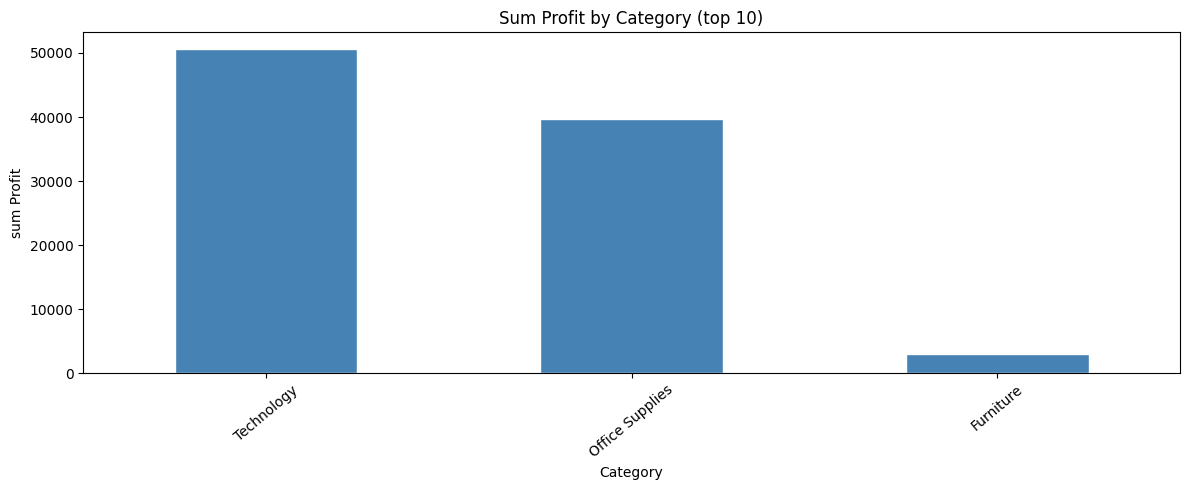

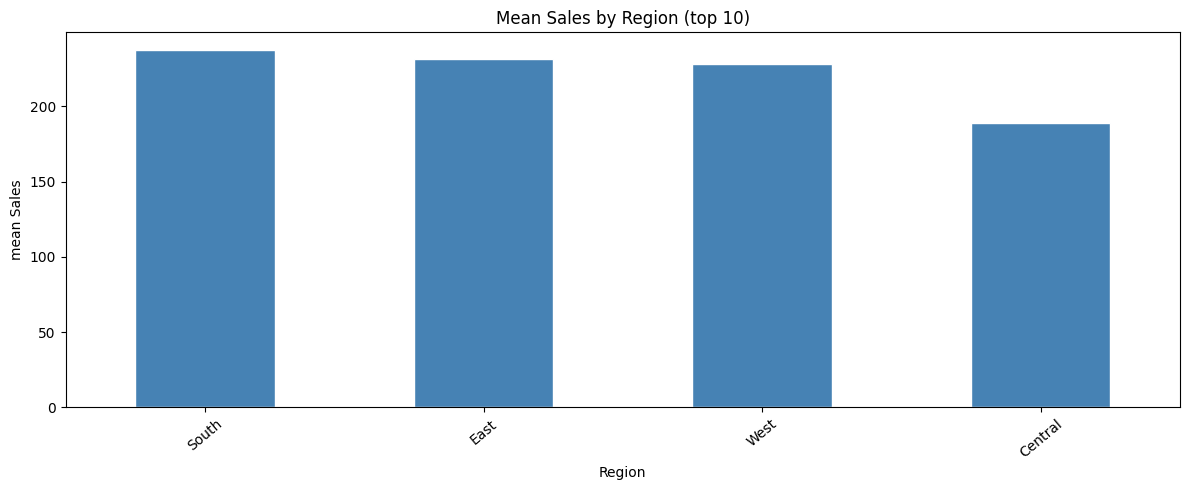

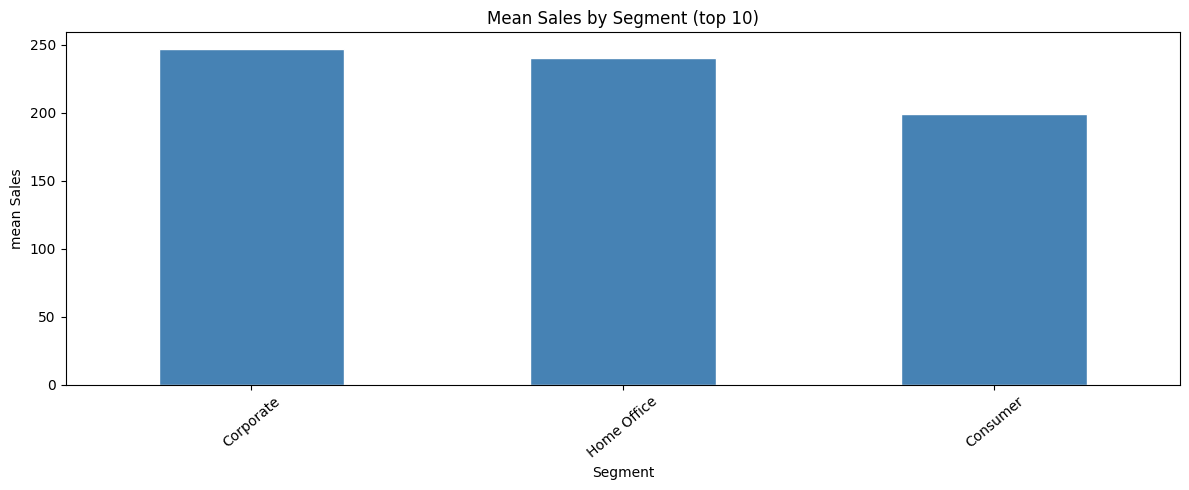


--- Scatter Plots ---


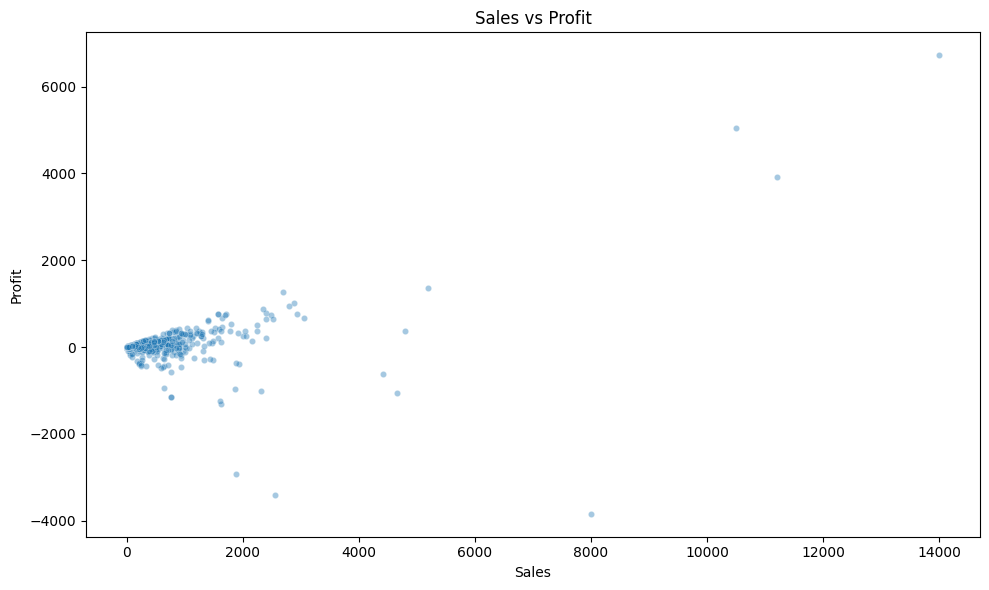

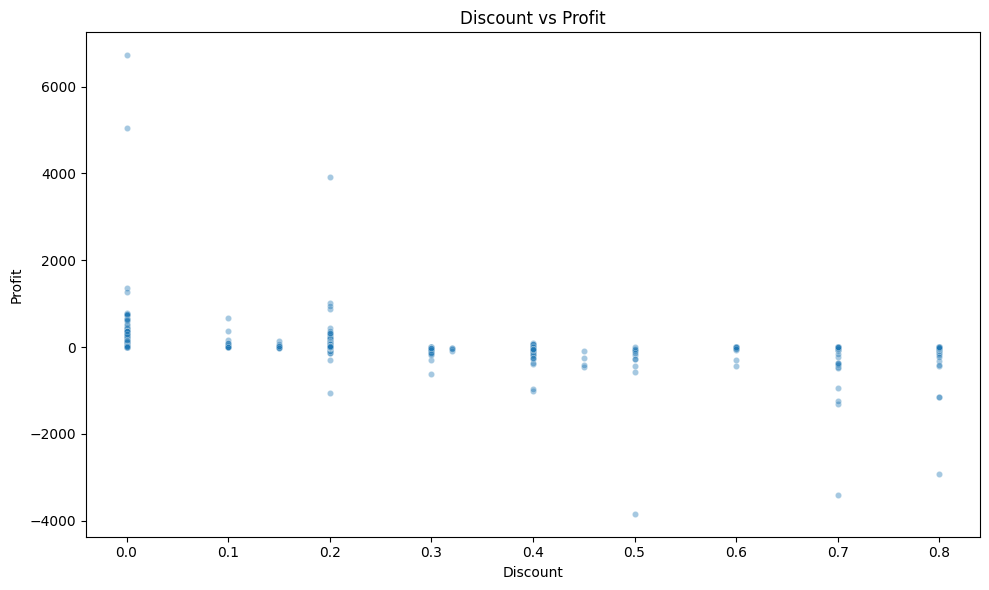


--- Pairplot ---


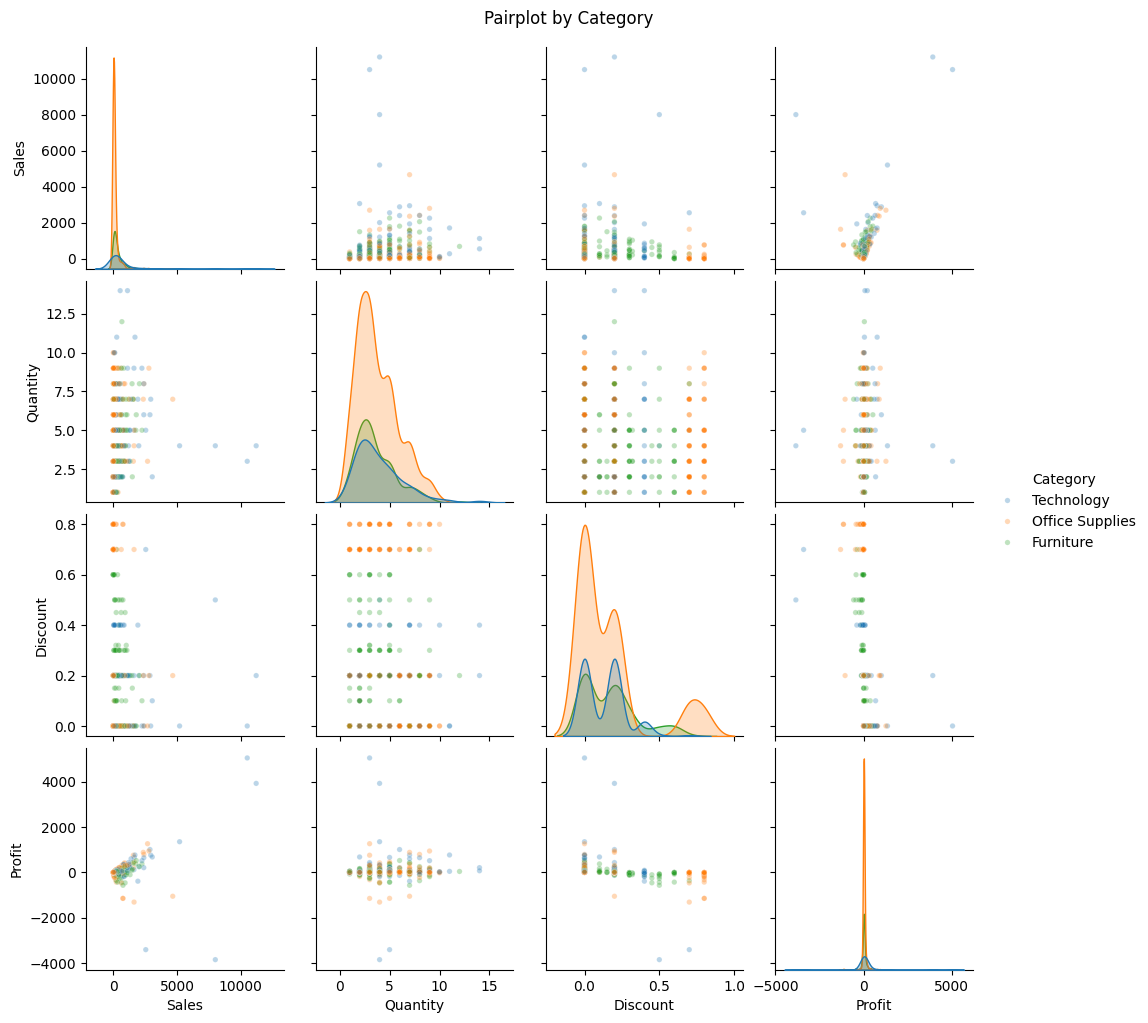


--- Line / Area Graphs ---


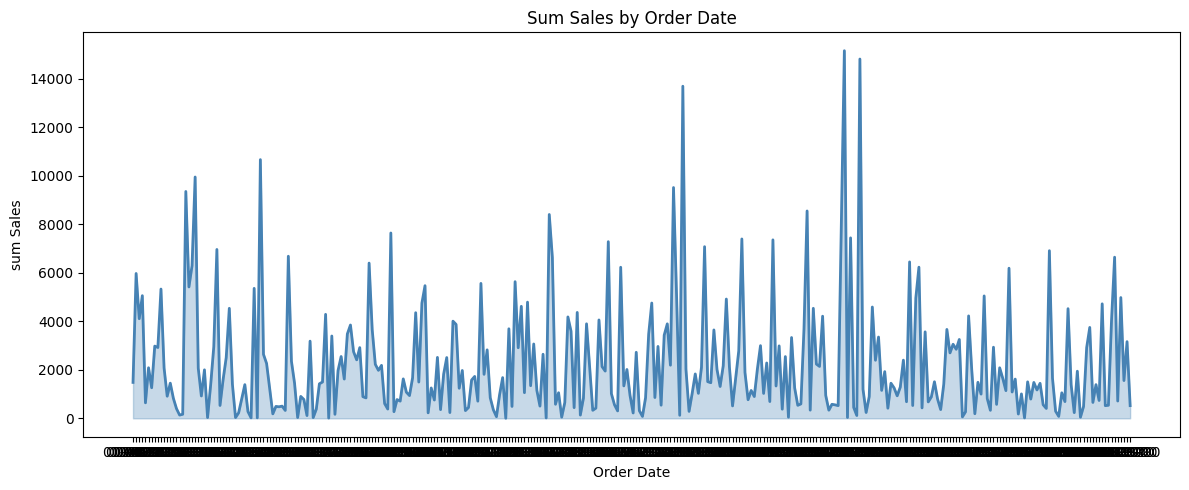

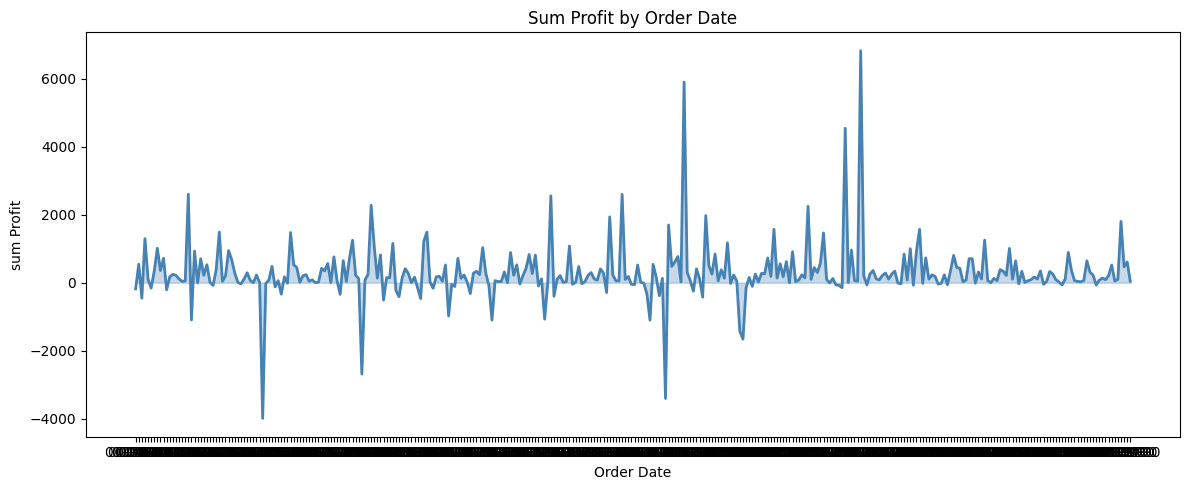

In [100]:
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
pairplot_cols = (
    ['Sales', 'Quantity', 'Discount', 'Profit'],
    'Category'
)
scatter_pairs = [
    ('Sales', 'Profit'),
    ('Discount', 'Profit'),
]
grouped_bar_pairs = [
    ('Category', 'Sales', 'sum'),
    ('Category', 'Profit', 'sum'),
    ('Region', 'Sales', 'mean'),
    ('Segment', 'Sales', 'mean'),
]
line_pairs = [
    ('Order Date', 'Sales', 'sum'),
     ('Order Date', 'Profit', 'sum')
]


analyze_dataset_bi_variate(
    df_us_ecomm_1,
    numeric_cols = numeric_cols,
    scatter_pairs=scatter_pairs,
    grouped_bar_pairs=grouped_bar_pairs,
    pairplot_cols=pairplot_cols,
    line_pairs=line_pairs,
    dataset_name='US E-Commerce Records'
)


/var/folders/xp/db574fvx2lq4165qj0ww45r40000gp/T/ipykernel_10986/3203579861.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'])


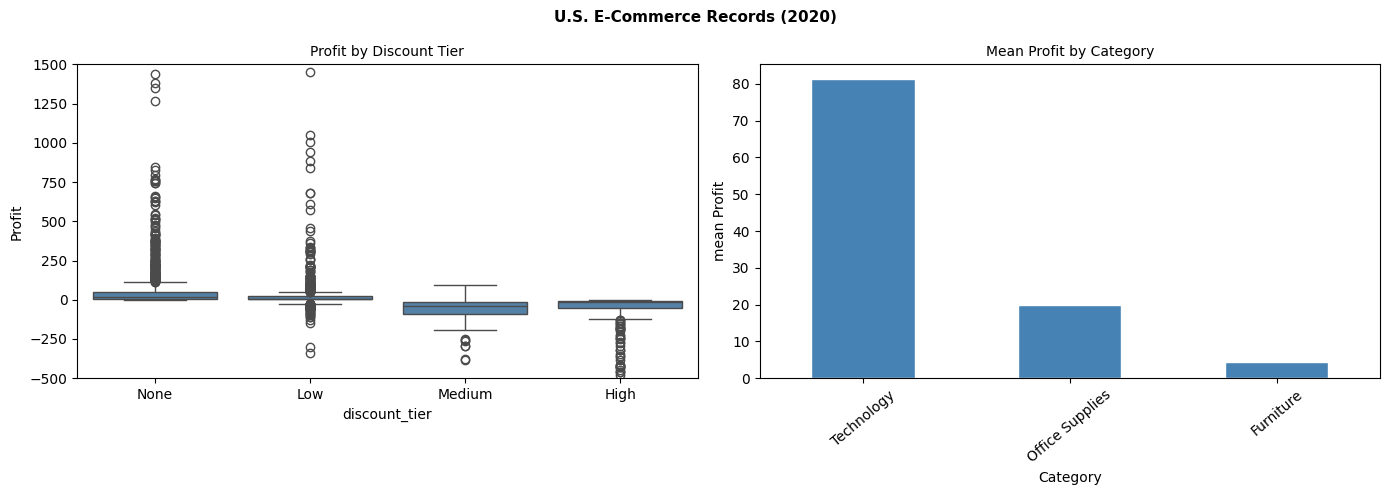

In [101]:

import os
os.makedirs('figures', exist_ok=True)
df = df_us_ecomm_1
df['Order Date'] = pd.to_datetime(df['Order Date'])

# ── Dataset label (change this per notebook) ──────────────────────
DATASET_TITLE = "U.S. E-Commerce Records (2020)"
# ──────────────────────────────────────────────────────────────────


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(DATASET_TITLE, fontsize=11, fontweight='bold')

# Left — Profit by Discount Tier
df['discount_tier'] = pd.cut(df['Discount'],
    bins=[-0.01, 0, 0.2, 0.4, 1.0],
    labels=['None', 'Low', 'Medium', 'High'])
sns.boxplot(data=df, x='discount_tier', y='Profit', ax=axes[0], color='steelblue')
axes[0].set_title('Profit by Discount Tier', fontsize=10)
axes[0].set_ylim(-500, 1500)

# Right — Mean Profit by Category
plot_grouped_bar(df, 'Category', 'Profit', axes[1], agg='mean')
axes[1].set_title('Mean Profit by Category', fontsize=10)

plt.tight_layout()
plt.show()


  Instacart Records — Bivariate Analysis

--- Grouped Bar Charts ---


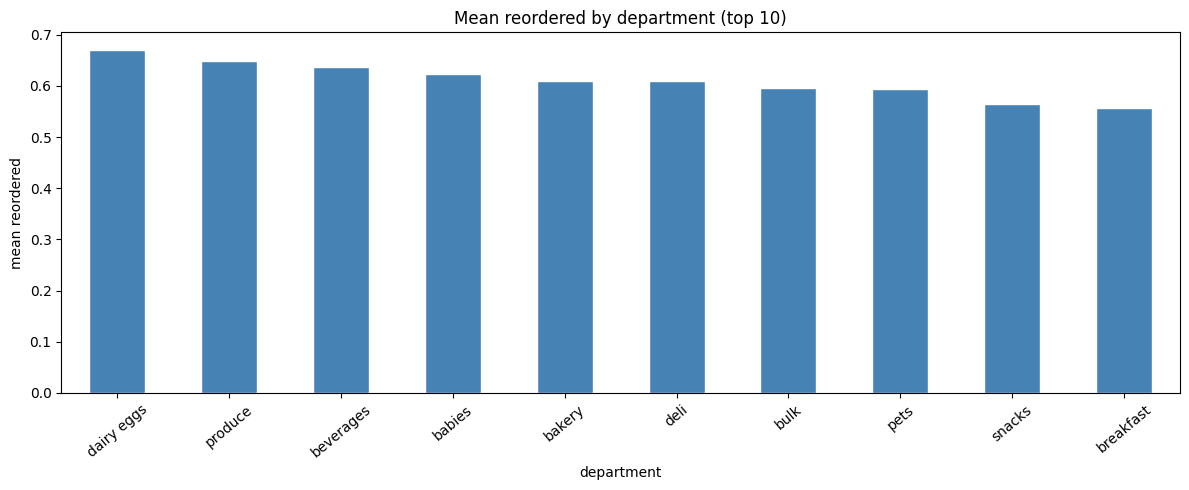

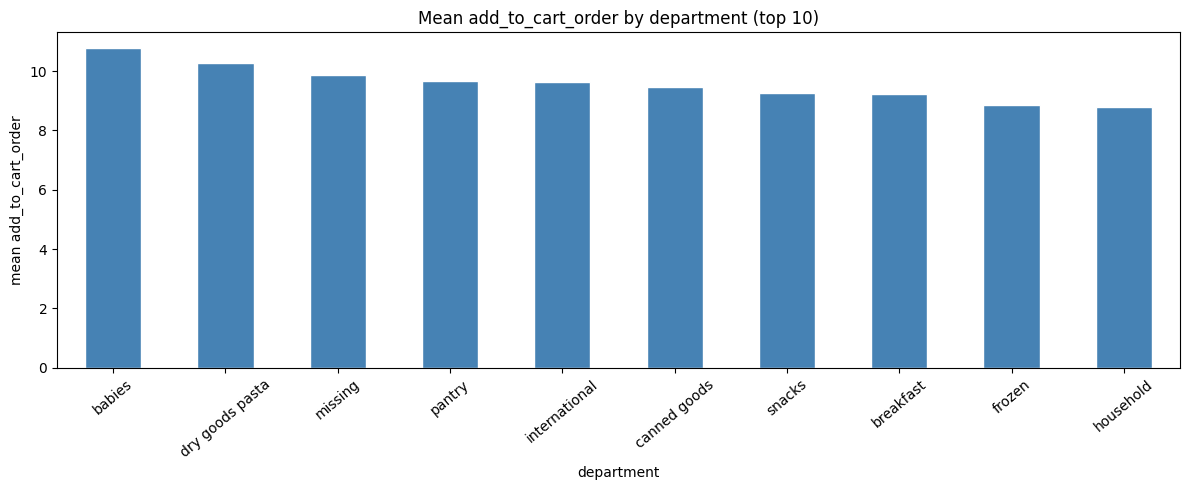


--- Category Heatmaps ---


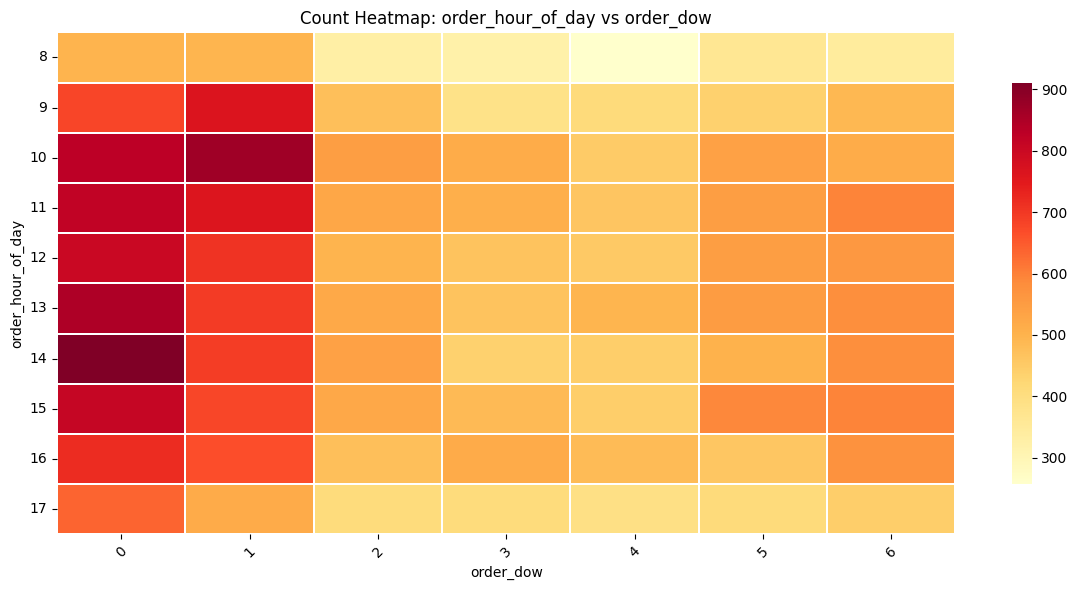


--- Line / Area Graphs ---


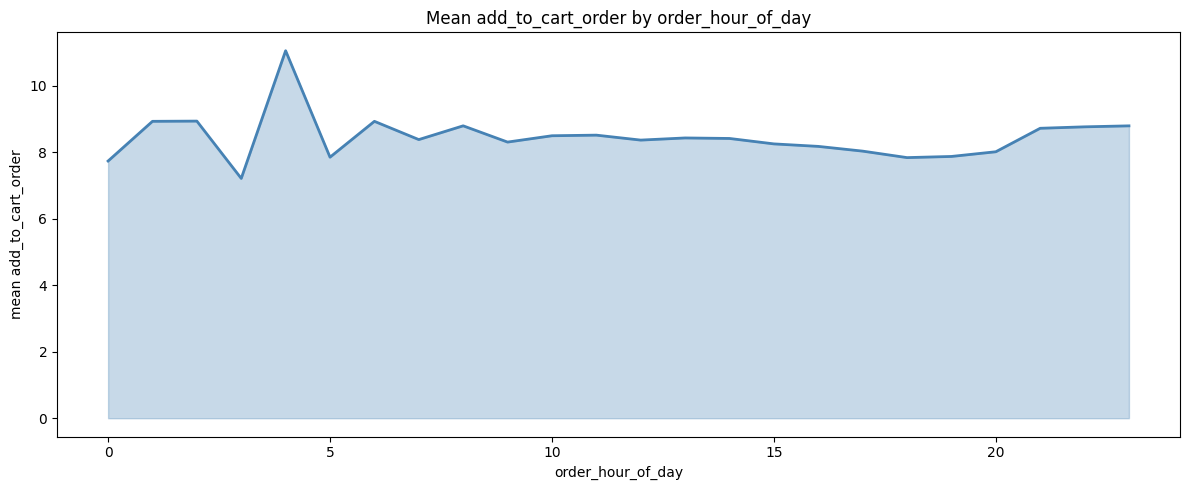

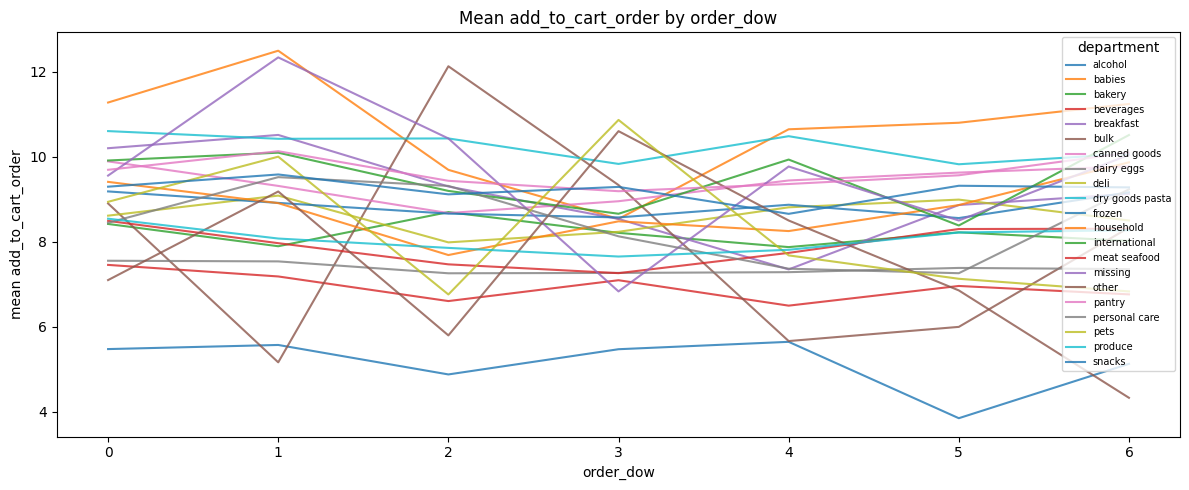

In [102]:
# Instacart bivariate analysis
# numeric cols to correlate (exclude IDs)
df = df_instacart
numeric_cols = [
    'order_dow', 'order_hour_of_day',
    'days_since_prior_order', 'add_to_cart_order', 'reordered'
]

# (numeric_col, cat_col)
boxplot_pairs = [
    ('add_to_cart_order', 'department'),   # basket depth by department
    ('days_since_prior_order', 'department'),
]

# (cat_col, numeric_col, agg)
grouped_bar_pairs = [
    ('department', 'reordered', 'mean'),   # reorder rate by department
    ('department', 'add_to_cart_order', 'mean'),
]

# (col_x, col_y) — both categorical or low-cardinality numeric
heatmap_pairs = [
    ('order_dow', 'order_hour_of_day'),    # shopping time patterns
]

# (col_x, col_y) or (col_x, col_y, hue_col)
scatter_pairs = [
    ('order_number', 'days_since_prior_order', 'department'),
]

pairplot_cols = (
    ['order_number', 'days_since_prior_order', 'add_to_cart_order', 'reordered'],
    None  # no hue — too many departments, would be noisy
)

line_pairs = [
    ('order_hour_of_day', 'add_to_cart_order', 'mean'),           # basket size across hours
    ('order_dow', 'add_to_cart_order', 'mean', 'department'),     # by day + department
]

analyze_dataset_bi_variate(
    df,
    numeric_cols=None,
    boxplot_pairs=None,
    grouped_bar_pairs=grouped_bar_pairs,
    heatmap_pairs=heatmap_pairs,
    scatter_pairs=None,
    pairplot_cols=None,
    line_pairs=line_pairs,
    dataset_name='Instacart Records'
)


  eCommerce Behavior — Bivariate Analysis

--- Grouped Bar Charts ---


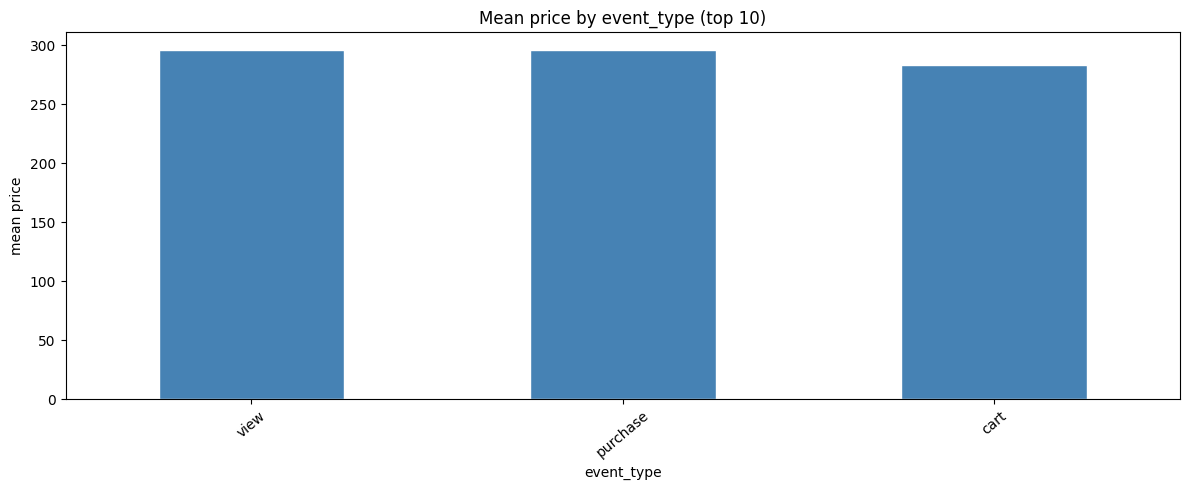

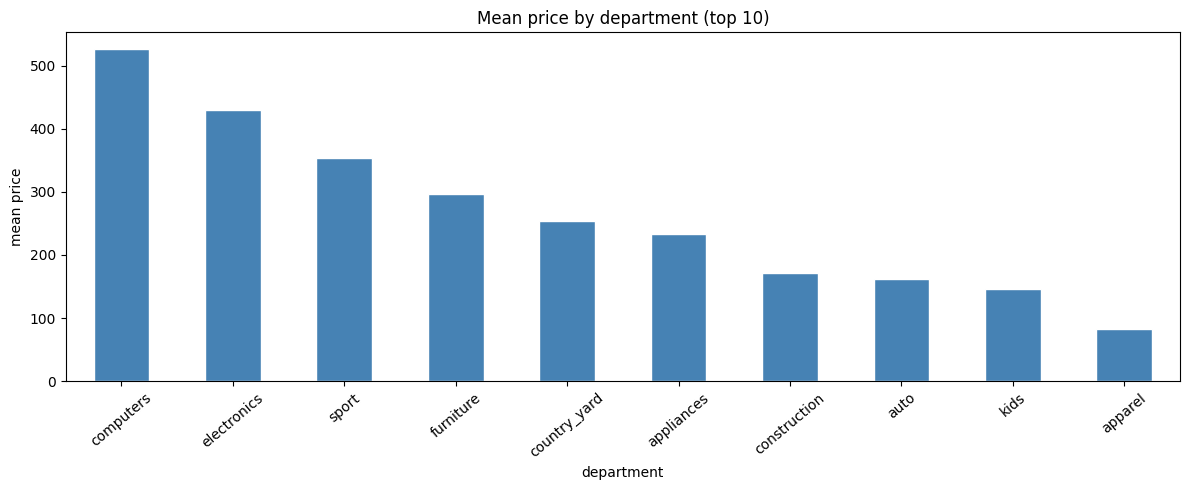


--- Category Heatmaps ---


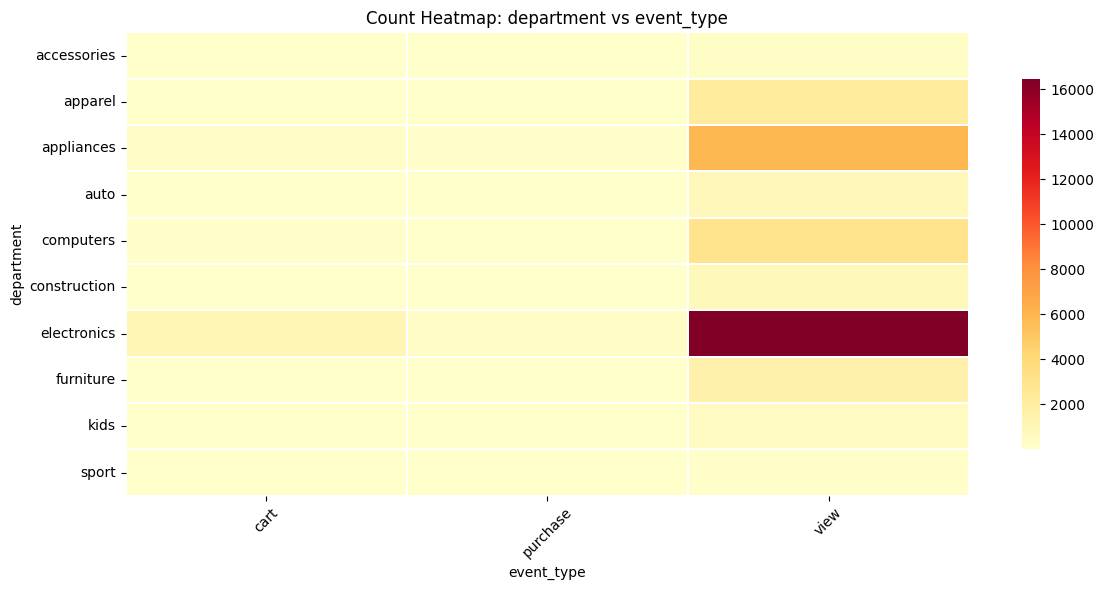

In [103]:
# E-Commerce Behavior bivariate analysis
# E-Commerce Behavior bivariate analysis
df = df_us_ecomm_2
df['event_time'] = pd.to_datetime(df['event_time'])

# Parse category hierarchy
split = df['category_code'].dropna().str.split('.')
df['department'] = split.str[0]
df['category'] = split.str[1]
df['subcategory'] = split.str[2]

numeric_cols = ['price']

# (numeric_col, cat_col)
boxplot_pairs = [
    ('price', 'event_type'),
    ('price', 'department'),
]

# (cat_col, numeric_col, agg)
grouped_bar_pairs = [
    ('event_type', 'price', 'mean'),
    ('department', 'price', 'mean'),
]

# (col_x, col_y) — two categoricals
heatmap_pairs = [
    ('event_type', 'department'),  # was category_code, now department — manageable cardinality
]

# skip — only one numeric col
scatter_pairs = []
pairplot_cols = None

line_pairs = [
    ('event_time', 'price', 'mean', 'event_type'),
    ('event_time', 'price', 'count', 'event_type'),
]

analyze_dataset_bi_variate(
    df,
    numeric_cols=None,
    boxplot_pairs=None,
    grouped_bar_pairs=grouped_bar_pairs,
    heatmap_pairs=heatmap_pairs,
    scatter_pairs=None,
    pairplot_cols=None,
    line_pairs=None,
    dataset_name='eCommerce Behavior'
)

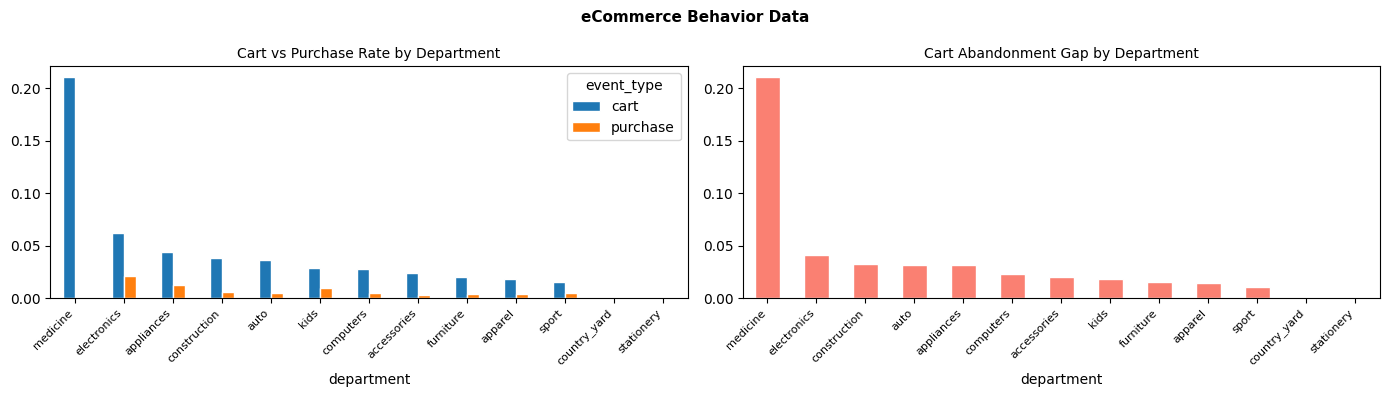

<Figure size 640x480 with 0 Axes>

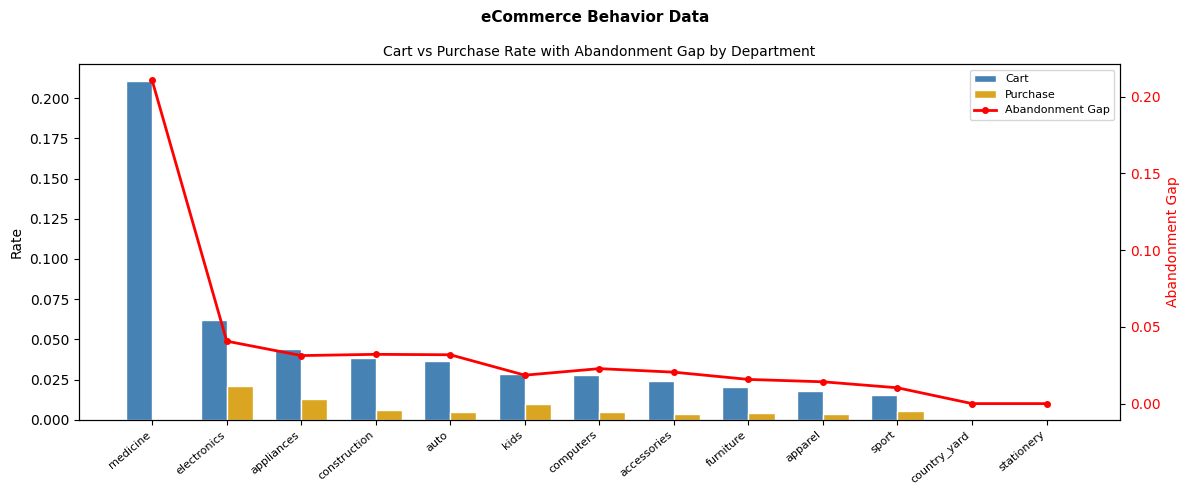

In [104]:
import os
import matplotlib.pyplot as plt
os.makedirs('figures', exist_ok=True)

os.makedirs('figures', exist_ok=True)
fig_size = (6, 5)

DATASET_TITLE = "eCommerce Behavior Data"


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(DATASET_TITLE, fontsize=11, fontweight='bold')


def clean_labels(ax, rotation=45, ha='right', fontsize=8):
    ax.tick_params(axis='x', rotation=rotation)
    ax.set_xticklabels(ax.get_xticklabels(), ha=ha, fontsize=fontsize)
    plt.tight_layout()

# Left — Cart vs Purchase rate by department
conversion = df[df['department'].notna()].groupby('department')['event_type']\
    .value_counts(normalize=True).unstack().fillna(0)
conversion[['cart', 'purchase']].sort_values('cart', ascending=False)\
    .plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].set_title('Cart vs Purchase Rate by Department', fontsize=10)
clean_labels(axes[0])

# Right — Cart abandonment gap
conversion['abandonment'] = conversion['cart'] - conversion['purchase']
conversion['abandonment'].sort_values(ascending=False)\
    .plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Cart Abandonment Gap by Department', fontsize=10)
clean_labels(axes[1])

plt.tight_layout()
plt.savefig('figures/fig6_behavior_bivariate.png', dpi=150)
plt.show()

plt.tight_layout()
plt.savefig('figures/fig3_behavior_univariate.png', dpi=150)
plt.show()


fig, ax1 = plt.subplots(figsize=(12, 5))
fig.suptitle(DATASET_TITLE, fontsize=11, fontweight='bold')

# Grouped bars — cart vs purchase
conversion = df[df['department'].notna()].groupby('department')['event_type']\
    .value_counts(normalize=True).unstack().fillna(0)
conversion['abandonment'] = conversion['cart'] - conversion['purchase']
conversion = conversion.sort_values('cart', ascending=False)

x = range(len(conversion))
width = 0.35
ax1.bar([i - width/2 for i in x], conversion['cart'], width, label='Cart', color='steelblue', edgecolor='white')
ax1.bar([i + width/2 for i in x], conversion['purchase'], width, label='Purchase', color='goldenrod', edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(conversion.index, rotation=40, ha='right', fontsize=8)
ax1.set_ylabel('Rate')
ax1.set_title('Cart vs Purchase Rate with Abandonment Gap by Department', fontsize=10)

# Line overlay — abandonment gap
ax2 = ax1.twinx()
ax2.plot(list(x), conversion['abandonment'], color='red', linewidth=2, marker='o', markersize=4, label='Abandonment Gap')
ax2.set_ylabel('Abandonment Gap', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.show()



## Conclusions

### Expected Findings
- Produce dominated Instacart purchases, consistent with grocery shopping behavior where fresh staples drive frequent orders (Figure 1)
- Sales and profit in the U.S. E-Commerce dataset were heavily right-skewed, with a small number of high-value transactions pulling the mean above the median (Figure 3)
- View events vastly outnumbered cart and purchase events in the eCommerce Behavior dataset, reflecting a typical browse-to-purchase funnel (Figure 4)
- Higher discounts corresponded with lower or negative profit in the U.S. E-Commerce data, particularly above the 0.4 threshold (Figure 6)

### Unexpected Findings
- Reorder rates across Instacart departments were surprisingly uniform (56–66%), with little variation between staple and discretionary categories (Figure 2)
- Discount values clustered at fixed tiers rather than varying continuously, suggesting a structured promotional policy rather than dynamic pricing (Figure 3)
- Medicine showed near-zero purchase conversion despite significant cart activity — likely a data quality issue or category-specific checkout barrier (Figure 7)

### Outliers
- Most visible in the U.S. E-Commerce scatter plots — high-sales transactions generally corresponded with higher profit, though with notable variance at the extremes

### Correlation
- Meaningful correlation analysis was only possible for the U.S. E-Commerce dataset given the limited numeric columns in the other two datasets

### Trends Over Time
- No strong temporal drift was observed that would invalidate cross-period comparisons

### Confounding Variables
- Medicine cart abandonment is the primary concern — near-complete absence of purchase events may reflect missing data or an external factor such as regulatory friction not captured in the dataset

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

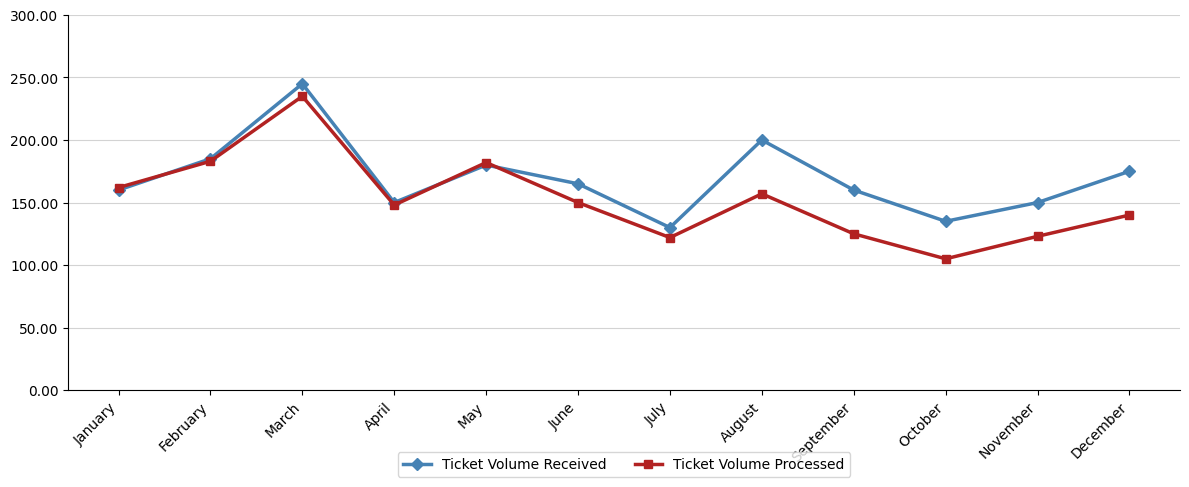

In [92]:
months = ['January', 'February', 'March', 'April', 'May', 'June',
          'July', 'August', 'September', 'October', 'November', 'December']

df_fake = pd.DataFrame({
    'month': months,
    'received':     [160, 185, 245, 150, 180, 165, 130, 200, 160, 135, 150, 175],
    'processed': [162, 183, 235, 148, 182, 150, 122, 157, 125, 105, 123, 140]
})

fig, ax = plt.subplots(figsize=(12, 5), facecolor='white')

ax.plot(df_fake.index, df_fake['received'], 
        marker='D', label='Ticket Volume Received', color='steelblue', linewidth=2.5)
ax.plot(df_fake.index, df_fake['processed'], 
        marker='s', label='Ticket Volume Processed', color='firebrick', linewidth=2.5)

ax.set_facecolor('white')
ax.grid(axis='y', color='lightgray', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)

ax.set_xticks(range(len(df_fake)))
ax.set_xticklabels(df_fake['month'], rotation=45, ha='right')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
ax.set_ylim(bottom=0, top=300)

plt.tight_layout()
plt.show()

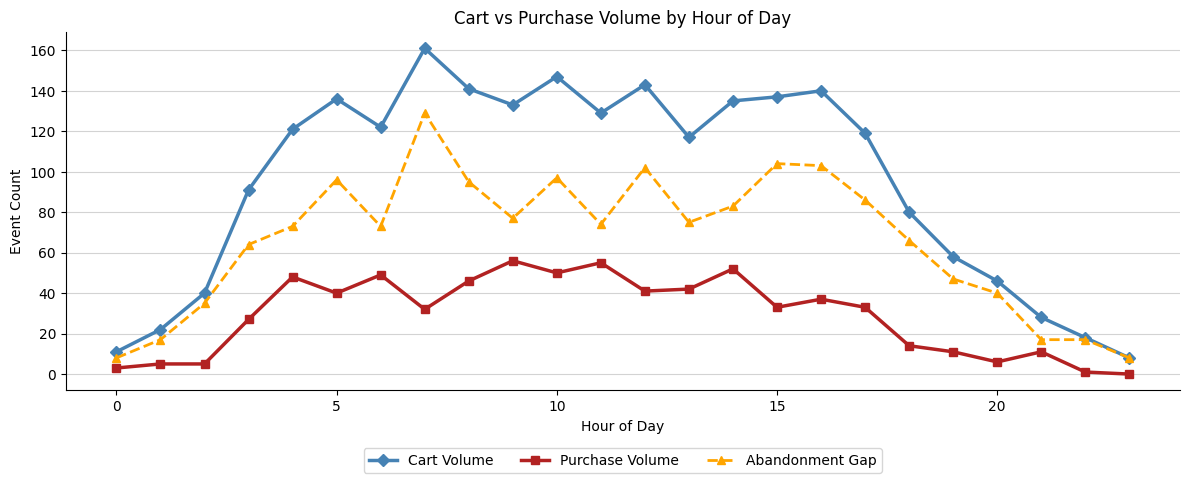

In [93]:
df['hour'] = df['event_time'].dt.hour

hourly_events = (
    df[df['event_type'].isin(['cart', 'purchase'])]
    .groupby(['hour', 'event_type'])
    .size()
    .unstack(fill_value=0)
)

hourly_events['abandonment'] = hourly_events['cart'] - hourly_events['purchase']


fig, ax = plt.subplots(figsize=(12, 5), facecolor='white')

ax.plot(hourly_events.index, hourly_events['cart'], 
        marker='D', label='Cart Volume', color='steelblue', linewidth=2.5)
ax.plot(hourly_events.index, hourly_events['purchase'], 
        marker='s', label='Purchase Volume', color='firebrick', linewidth=2.5)
ax.plot(hourly_events.index, hourly_events['abandonment'], 
        marker='^', label='Abandonment Gap', color='orange', linewidth=2, linestyle='--')

ax.set_facecolor('white')
ax.grid(axis='y', color='lightgray', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title('Cart vs Purchase Volume by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Event Count')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)

plt.tight_layout()
plt.show()
